# Convolutional Neural Networks

Aluno: Paulo Henrique L. Dantas | 221022408

O objetivo desse trabalho é criar uma Convolutional Neural Network do zero e aplicar no dataset oferecido pela kaggle para classificar nuvens:

[dataset aqui](https://www.kaggle.com/competitions/classificandos-nuvens-usando-cnn/data)

Após a criação de um modelo do zero, é necessário testar com um outro modelo já existente e realizar a comparação

## Instalando Pytorch

In [ ]:
!pip uninstall torch torchvision torchaudio -y

Found existing installation: torch 2.3.1+rocm6.0
Uninstalling torch-2.3.1+rocm6.0:
  Successfully uninstalled torch-2.3.1+rocm6.0
Found existing installation: torchvision 0.18.1+cu118
Uninstalling torchvision-0.18.1+cu118:
  Successfully uninstalled torchvision-0.18.1+cu118
Found existing installation: torchaudio 2.6.0+cu124
Uninstalling torchaudio-2.6.0+cu124:
  Successfully uninstalled torchaudio-2.6.0+cu124


In [ ]:
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118

Looking in indexes: https://download.pytorch.org/whl/cu118


## Criando uma CNN from scratch usando pytorch

In [17]:
# Realizando todas as importações necessárias e tentando inicilizar o CUDA
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import os
import shutil

dataset_root = '/content/data'
train_dir = os.path.join(dataset_root, 'clouds_train')
test_dir = os.path.join(dataset_root, 'clouds_test')

print("Checking for and removing .ipynb_checkpoints directories...")

for root, dirs, files in os.walk(train_dir):
    if '.ipynb_checkpoints' in dirs:
        checkpoint_path = os.path.join(root, '.ipynb_checkpoints')
        print(f"Deleting: {checkpoint_path}")
        shutil.rmtree(checkpoint_path)

for root, dirs, files in os.walk(test_dir):
    if '.ipynb_checkpoints' in dirs:
        checkpoint_path = os.path.join(root, '.ipynb_checkpoints')
        print(f"Deleting: {checkpoint_path}")
        shutil.rmtree(checkpoint_path)

print("Finished checking and removing .ipynb_checkpoints.")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"using the: {device}")

Checking for and removing .ipynb_checkpoints directories...
Finished checking and removing .ipynb_checkpoints.
using the: cpu


In [20]:
# Definindo transforamções para o treinamento
train_transforms = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Definindo transformações para validão do set de test
val_transforms = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Carregando dataset usando ImageFolder
train_dataset = datasets.ImageFolder(train_dir, transform=train_transforms)
test_dataset = datasets.ImageFolder(test_dir, transform=val_transforms)

# Pegar o número de classes
num_classes = len(train_dataset.classes)
print(f"Number of classes: {num_classes}")
print(f"Classes: {train_dataset.classes}")

Number of classes: 7
Classes: ['cirriform clouds', 'clear sky', 'cumulonimbus clouds', 'cumulus clouds', 'high cumuliform clouds', 'stratiform clouds', 'stratocumulus clouds']


In [21]:
# Criando DataLoaders
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

## Criando o Modelo com pytorch

In [34]:
# Criando função CNN Model from scratch
class SimpleCNN(nn.Module):
  def __init__(self, num_classes):
    super(SimpleCNN, self).__init__()
    # Primeiro bloco
    self.conv1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1)
    self.bn1 = nn.BatchNorm2d(32)
    self.relu1 = nn.ReLU()
    self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
    self.dropout1 = nn.Dropout(0.25)

    # Segundo bloco
    self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
    self.bn2 = nn.BatchNorm2d(64)
    self.relu2 = nn.ReLU()
    self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)
    self.dropout2 = nn.Dropout(0.25)

    # Terceiro bloco
    self.conv3 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1)
    self.bn3 = nn.BatchNorm2d(128)
    self.relu3 = nn.ReLU()
    self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2)
    self.dropout3 = nn.Dropout(0.25)

    self.fc1 = nn.Linear(128*28*28, 512)
    self.relu_fc = nn.ReLU()
    self.dropout_fc = nn.Dropout(0.5)
    self.fc2 = nn.Linear(512, num_classes)
    self.dropout_fc = nn.Dropout(0.5)

  def forward(self, x):
    x = self.pool1(self.dropout1(self.relu1(self.bn1(self.conv1(x)))))
    x = self.dropout1(x)

    x = self.pool2(self.dropout2(self.relu2(self.bn2(self.conv2(x)))))
    x = self.dropout2(x)

    x = self.pool3(self.dropout3(self.relu3(self.bn3(self.conv3(x)))))
    x = self.dropout3(x)

    x = x.view(x.size(0), -1)
    x = self.relu_fc(self.fc1(x))
    x = self.dropout_fc(x)
    x = self.fc2(x)

    return x

## Treinando o Modelo

In [35]:
# Importando modelo
model = SimpleCNN(num_classes=num_classes).to(device)
print(model)

SimpleCNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu1): ReLU()
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout1): Dropout(p=0.25, inplace=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu2): ReLU()
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout2): Dropout(p=0.25, inplace=False)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu3): ReLU()
  (pool3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout3): Dropout(p=0.25, inplace=False)
  (fc1): Linear(in_features=100352, out_fea

In [36]:
# Loop de treinamento
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

num_epochs = 20
train_losses = []
test_losses = []
test_acuracies = []

print("Starting Training")
for epoch in range(num_epochs):
  model.train()
  train_loss = 0.0
  for inputs, labels in train_loader:
    inputs, labels = inputs.to(device), labels.to(device)
    optimizer.zero_grad()
    outputs = model(inputs)
    loss = criterion(outputs, labels)
    loss.backward()
    optimizer.step()
    train_loss += loss.item() * inputs.size(0)

  epoch_train_loss = train_loss / len(train_loader.dataset)
  train_losses.append(epoch_train_loss)

  model.eval()
  running_test_loss = 0.0
  correct_predictions = 0
  total_predictions = 0

  with torch.no_grad():
    for inputs, labels in test_loader:
      inputs, labels = inputs.to(device), labels.to(device)

      outputs = model(inputs)
      loss = criterion(outputs, labels)
      running_test_loss += loss.item() * inputs.size(0)

      _, predicted = torch.max(outputs.data, 1)
      total_predictions += labels.size(0)
      correct_predictions += (predicted == labels).sum().item()

    epoch_test_loss = running_test_loss / len(test_loader.dataset)
    test_losses.append(epoch_test_loss)
    epoch_test_accuracy = correct_predictions / total_predictions
    test_acuracies.append(epoch_test_accuracy)

    print(f"Epoch [{epoch+1}/{num_epochs}], Train Loss: {epoch_train_loss:.4f}, Test Loss: {epoch_test_loss:.4f}, Test Accuracy: {epoch_test_accuracy:.4f}")

print("Training ended")


Starting Training
Epoch [1/20], Train Loss: 41.7446, Test Loss: 9.7576, Test Accuracy: 0.2737
Epoch [2/20], Train Loss: 12.7765, Test Loss: 2.1207, Test Accuracy: 0.2531
Epoch [3/20], Train Loss: 2.6572, Test Loss: 1.7244, Test Accuracy: 0.2654
Epoch [4/20], Train Loss: 1.9475, Test Loss: 1.6683, Test Accuracy: 0.2984
Epoch [5/20], Train Loss: 1.9530, Test Loss: 1.6563, Test Accuracy: 0.3189
Epoch [6/20], Train Loss: 1.7972, Test Loss: 1.7426, Test Accuracy: 0.2016
Epoch [7/20], Train Loss: 1.7750, Test Loss: 1.6706, Test Accuracy: 0.3189
Epoch [8/20], Train Loss: 1.7780, Test Loss: 1.6030, Test Accuracy: 0.3683
Epoch [9/20], Train Loss: 1.6603, Test Loss: 1.6330, Test Accuracy: 0.3230
Epoch [10/20], Train Loss: 1.6469, Test Loss: 1.5676, Test Accuracy: 0.3395
Epoch [11/20], Train Loss: 1.6838, Test Loss: 1.5692, Test Accuracy: 0.3148
Epoch [12/20], Train Loss: 1.6227, Test Loss: 1.5057, Test Accuracy: 0.3169
Epoch [13/20], Train Loss: 1.6208, Test Loss: 1.5343, Test Accuracy: 0.3189
E

## Plotando Resultados


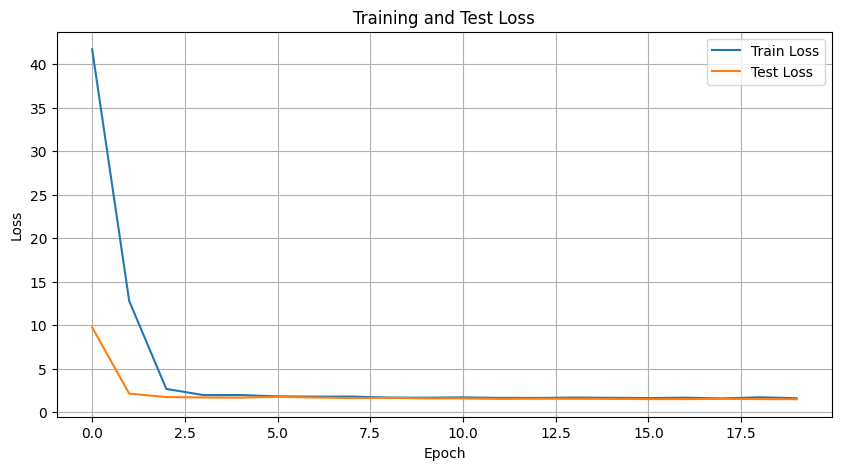

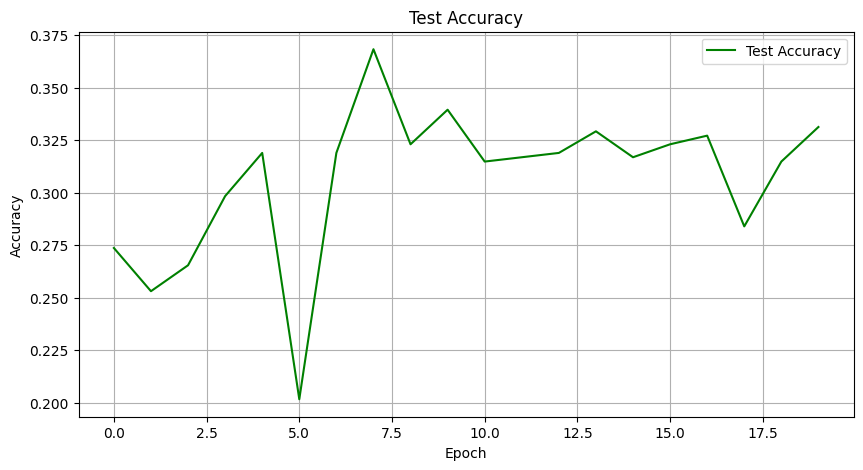

In [38]:
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss')
plt.plot(test_losses, label='Test Loss')
plt.title('Training and Test Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(test_acuracies, label='Test Accuracy', color='green')
plt.title('Test Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

## Treinando com outro modelo já otimizado

In [41]:
model_ft = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

num_ftrs = model_ft.fc.in_features
model_ft.fc = nn.Linear(num_ftrs, num_classes)

model_ft = model_ft.to(device)

print(model_ft)

optimizer_ft = optim.Adam(model_ft.fc.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

num_epochs_ft = 15

train_losses_ft = []
test_losses_ft = []
test_accuracies_ft = []

print("Starting training")
for epoch in range(num_epochs_ft):
    # Training phase
    model_ft.train()
    running_loss = 0.0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer_ft.zero_grad()

        outputs = model_ft(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer_ft.step()

        running_loss += loss.item() * inputs.size(0)

    epoch_train_loss = running_loss / len(train_dataset)
    train_losses_ft.append(epoch_train_loss)

    # Evaluation phase
    model_ft.eval()
    running_test_loss = 0.0
    correct_predictions = 0
    total_predictions = 0

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            outputs = model_ft(inputs)
            loss = criterion(outputs, labels)
            running_test_loss += loss.item() * inputs.size(0)

            _, predicted = torch.max(outputs.data, 1)
            total_predictions += labels.size(0)
            correct_predictions += (predicted == labels).sum().item()

    epoch_test_loss = running_test_loss / len(test_dataset)
    test_losses_ft.append(epoch_test_loss)
    epoch_test_accuracy = correct_predictions / total_predictions
    test_accuracies_ft.append(epoch_test_accuracy)

    print(f"Epoch {epoch+1}/{num_epochs_ft}: "
          f"Train Loss: {epoch_train_loss:.4f}, "
          f"Test Loss: {epoch_test_loss:.4f}, "
          f"Test Accuracy: {epoch_test_accuracy:.4f}")

print("Training ended")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 93.2MB/s]


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

## Plotando resultados

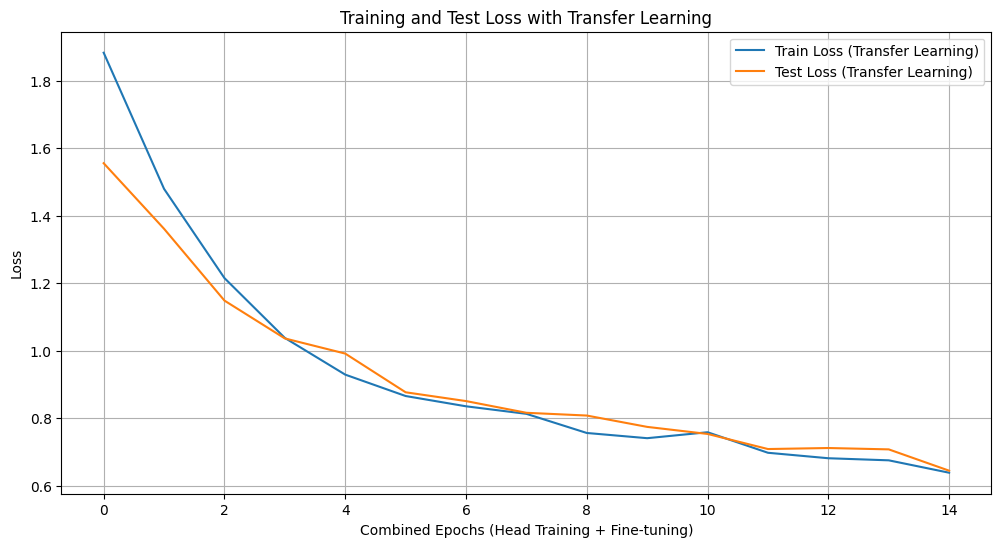

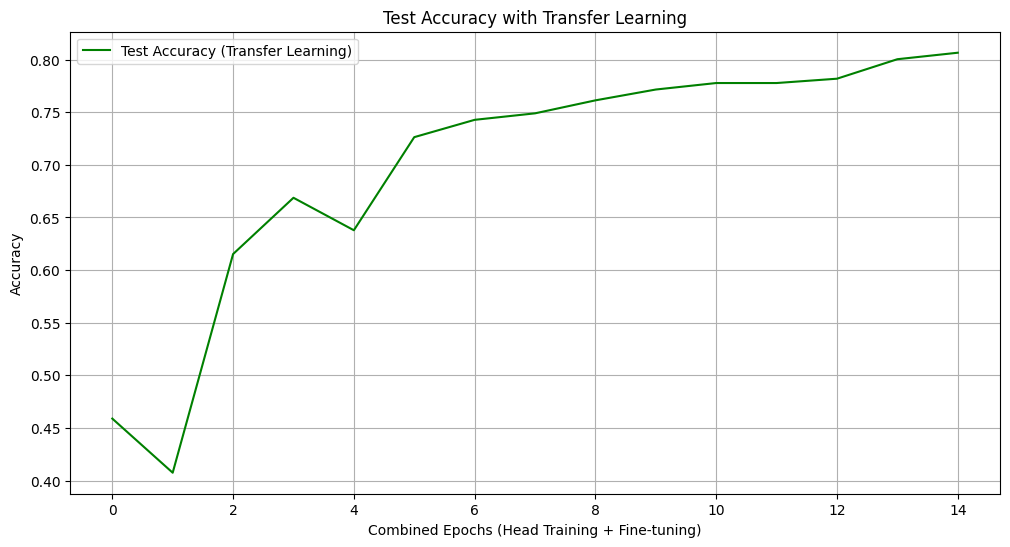

In [42]:
plt.figure(figsize=(12, 6))
plt.plot(train_losses_ft, label='Train Loss (Transfer Learning)')
plt.plot(test_losses_ft, label='Test Loss (Transfer Learning)')
plt.title('Training and Test Loss with Transfer Learning')
plt.xlabel('Combined Epochs (Head Training + Fine-tuning)')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(12, 6))
plt.plot(test_accuracies_ft, label='Test Accuracy (Transfer Learning)', color='green')
plt.title('Test Accuracy with Transfer Learning')
plt.xlabel('Combined Epochs (Head Training + Fine-tuning)')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

## Comparação dos dois modelos

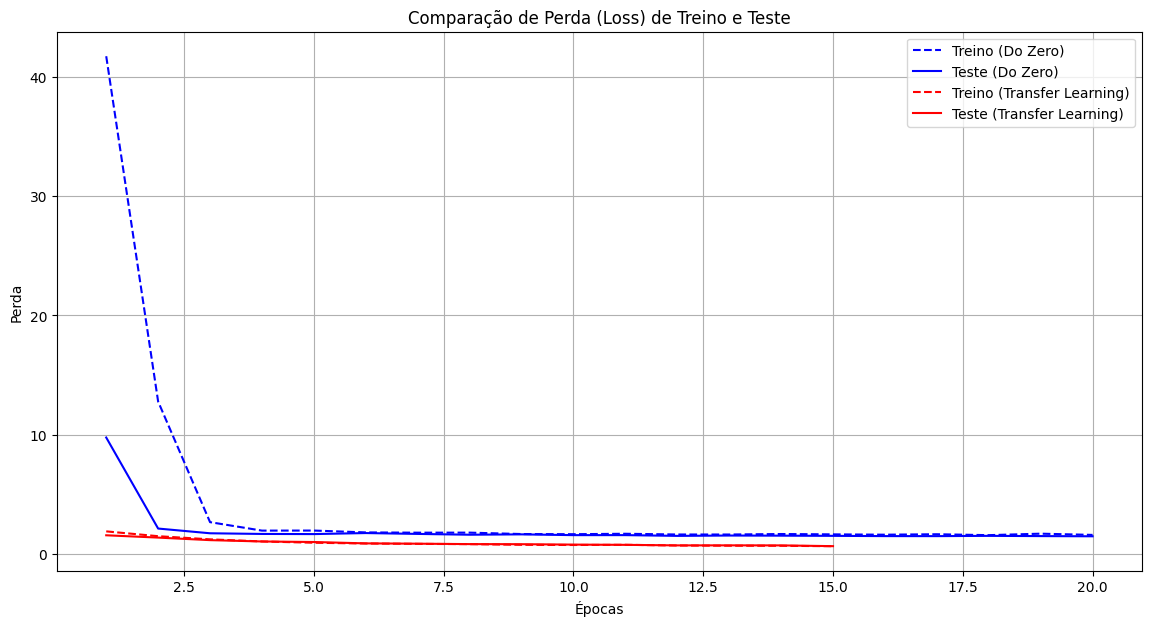

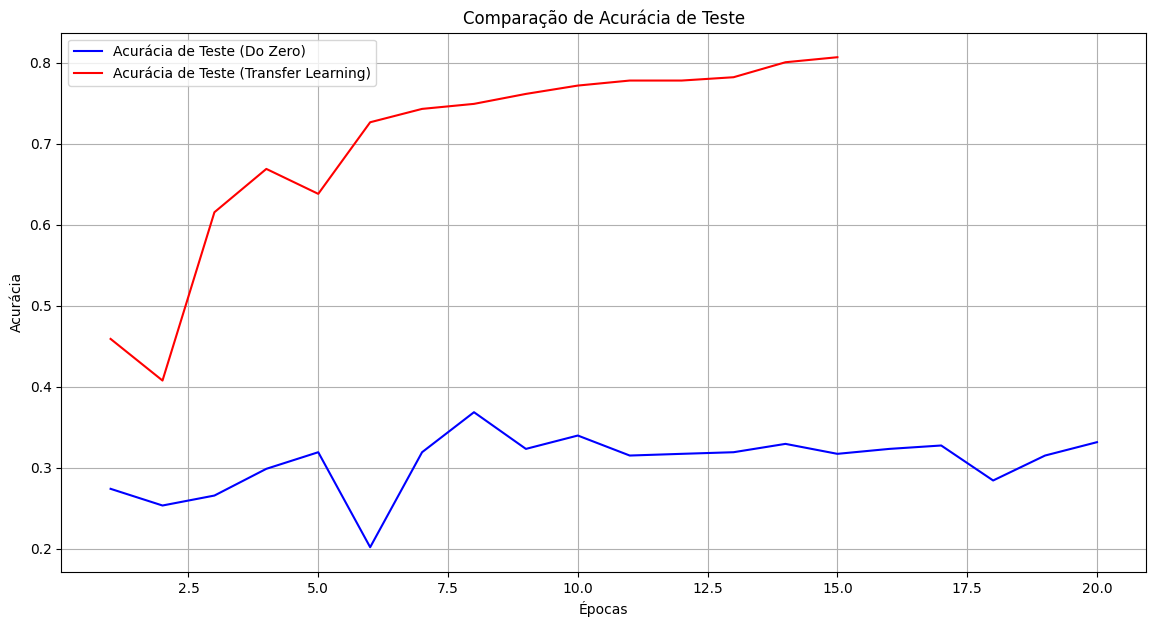

In [43]:
# Dados do modelo 'do zero'
epochs_scratch = 20
train_losses_scratch = [41.7446, 12.7765, 2.6572, 1.9475, 1.9530, 1.7972, 1.7750, 1.7780, 1.6603, 1.6469, 1.6838, 1.6227, 1.6208, 1.6622, 1.6335, 1.6054, 1.6439, 1.5666, 1.6911, 1.5877]
test_losses_scratch = [9.7576, 2.1207, 1.7244, 1.6683, 1.6563, 1.7426, 1.6706, 1.6030, 1.6330, 1.5676, 1.5692, 1.5057, 1.5343, 1.5235, 1.5086, 1.4870, 1.4853, 1.5077, 1.4883, 1.4714]
test_accuracies_scratch = [0.2737, 0.2531, 0.2654, 0.2984, 0.3189, 0.2016, 0.3189, 0.3683, 0.3230, 0.3395, 0.3148, 0.3169, 0.3189, 0.3292, 0.3169, 0.3230, 0.3272, 0.2840, 0.3148, 0.3313]

# Dados do modelo de Transfer Learning (ResNet-18)
epochs_transfer = 15
train_losses_transfer = [1.8836, 1.4799, 1.2154, 1.0380, 0.9292, 0.8657, 0.8352, 0.8129, 0.7561, 0.7407, 0.7583, 0.6974, 0.6812, 0.6750, 0.6383]
test_losses_transfer = [1.5560, 1.3616, 1.1487, 1.0365, 0.9916, 0.8768, 0.8507, 0.8160, 0.8078, 0.7742, 0.7533, 0.7085, 0.7115, 0.7075, 0.6443]
test_accuracies_transfer = [0.4588, 0.4074, 0.6152, 0.6687, 0.6379, 0.7263, 0.7428, 0.7490, 0.7613, 0.7716, 0.7778, 0.7778, 0.7819, 0.8004, 0.8066]

# Plotar Perdas (Losses)
plt.figure(figsize=(14, 7))
plt.plot(range(1, epochs_scratch + 1), train_losses_scratch, label='Treino (Do Zero)', linestyle='--', color='blue')
plt.plot(range(1, epochs_scratch + 1), test_losses_scratch, label='Teste (Do Zero)', color='blue')
plt.plot(range(1, epochs_transfer + 1), train_losses_transfer, label='Treino (Transfer Learning)', linestyle='--', color='red')
plt.plot(range(1, epochs_transfer + 1), test_losses_transfer, label='Teste (Transfer Learning)', color='red')

plt.title('Comparação de Perda (Loss) de Treino e Teste')
plt.xlabel('Épocas')
plt.ylabel('Perda')
plt.legend()
plt.grid(True)
plt.show()

# Plotar Acurácias (Accuracies)
plt.figure(figsize=(14, 7))
plt.plot(range(1, epochs_scratch + 1), test_accuracies_scratch, label='Acurácia de Teste (Do Zero)', color='blue')
plt.plot(range(1, epochs_transfer + 1), test_accuracies_transfer, label='Acurácia de Teste (Transfer Learning)', color='red')

plt.title('Comparação de Acurácia de Teste')
plt.xlabel('Épocas')
plt.ylabel('Acurácia')
plt.legend()
plt.grid(True)
plt.show()

## Resultados

Ao comparar os resultados do seu modelo treinado "do zero" e o modelo utilizando Transfer Learning (ResNet-18), as diferenças são BRUTAIS!! E demonstram a eficácia do Transfer Learning para tarefas de classificação de imagens com datasets menores.


Modelo "Do Zero": Atingiu uma acurácia máxima de aproximadamente 36.83% (na epoch 8) e terminou em 33.13%. Isso é um desempenho muito baixo, apenas um pouco melhor do que chutar aleatoriamente em um problema multiclasse (se tiver 3 classes, a chance aleatória é 33.33%). Isso sugere que o modelo não conseguiu aprender características significativas das imagens de nuvens a partir do zero com a quantidade de dados e epochs disponíveis. (Como já diriam, é melhor então jogar na moeda)

Modelo com Transfer Learning: Atingiu uma acurácia de teste final de 80.66% na epoch 15. Este é um salto enorme em desempenho, indicando que o modelo aprendeu a classificar as nuvens com alta precisão.

O que já era esperado, visto que um problema de CNN demanda um dataset mais largo e um treinamento mais complexo